# Deep Residual 2D CNN on Raw 1D ECG Signals

**Paper:** [Deep Residual 2D Convolutional Neural Network for Cardiovascular Disease Classification](https://www.nature.com/articles/s41598-024-72382-3)  
**Repo:** `DataMining/ECG-classification` (HaneenElyamani)  
**Dataset:** PTB-XL — multi-label ECG classification (MI, STTC, CD, HYP)  

### Key difference from AlexNet_ECG_Local
- **No image conversion** — works directly on raw 1D ECG signals
- **Architecture** — Deep Residual 2D CNN with kernels `(1, k)` per-lead and `(leads, 1)` cross-lead merger
- **Much faster preprocessing** — no GAF/MTF/RP computation needed
- **Same data** — loads from existing `PTB-XL-ECG` pickles

## 1. Configuration

In [1]:
import os

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR       = '/home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG'
MODEL_SAVE_DIR = os.path.join(BASE_DIR, 'models_residual_cnn')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── LEAD SELECTION ────────────────────────────────────────────────────────────
# 12-lead order: I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5, V6
# Indices:       0   1   2    3    4    5   6   7   8   9  10  11
# Use 3 leads to match AlexNet paper (I, II, V2)
LEAD_INDICES = [0, 1, 7]   # Lead I, II, V2
NUM_LEADS    = len(LEAD_INDICES)

# ── HYPERPARAMETERS ───────────────────────────────────────────────────────────
EPOCHS        = 100
BATCH_SIZE    = 256
LEARNING_RATE = 0.0005   # Adam works better than SGD=0.01 for this architecture
N_CLASSES     = 4
PATIENCE      = 20
SEED          = 42

SPLIT_SIZES = [17111, 2156, 2163]

print(f'Config OK | Leads: {NUM_LEADS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')

Config OK | Leads: 3 | Batch: 256 | LR: 0.0005


## 2. Imports

In [2]:
import random
import pickle
import statistics
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, sosfilt
from sklearn.metrics import roc_auc_score, roc_curve

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: cuda


## 3. Reproducibility

In [3]:
def configure_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

configure_seed(SEED)

## 4. Data Loading & Preprocessing

Loads raw signals from the PTB-XL-ECG pickles — **no image conversion needed**.

Model input shape: `(batch, 1, num_leads, 1000)` — treating leads as height, time as width.

In [4]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

print('Loading data...')
X_train_raw = np.array(load_pickle(os.path.join(BASE_DIR, 'X_train_processed.pickle')))
X_dev_raw   = np.array(load_pickle(os.path.join(BASE_DIR, 'X_dev_processed.pickle')))
X_test_raw  = np.array(load_pickle(os.path.join(BASE_DIR, 'X_test_processed.pickle')))
y_train     = np.array(load_pickle(os.path.join(BASE_DIR, 'y_train_processed.pickle'))).astype('float32')
y_dev       = np.array(load_pickle(os.path.join(BASE_DIR, 'y_dev_processed.pickle'))).astype('float32')
y_test      = np.array(load_pickle(os.path.join(BASE_DIR, 'y_test_processed.pickle'))).astype('float32')

print(f'X_train raw shape: {X_train_raw.shape}')
print(f'X_dev   raw shape: {X_dev_raw.shape}')
print(f'X_test  raw shape: {X_test_raw.shape}')
print(f'y_train shape:     {y_train.shape}')
print(f'y_train sample:    {y_train[0]}  (expected: 4-class multilabel [MI, STTC, CD, HYP])')

Loading data...
X_train raw shape: (17111, 1000, 12)
X_dev   raw shape: (2156, 1000, 12)
X_test  raw shape: (2163, 1000, 12)
y_train shape:     (17111, 4)
y_train sample:    [0. 0. 0. 0.]  (expected: 4-class multilabel [MI, STTC, CD, HYP])


In [5]:
# Bandpass filter: 1–45 Hz at 100 Hz sampling rate (same as AlexNet paper)
band_pass_filter = butter(2, [1, 45], 'bandpass', fs=100, output='sos')

def preprocess_signals(X_raw, lead_indices):
    """
    X_raw: (N, 1000, total_leads) or (N, 1000, 12)
    Returns: (N, 1, num_leads, 1000)  — model input format
      - 1      : channel dimension (single input channel for Conv2d)
      - num_leads : height (treated as spatial height in 2D conv)
      - 1000   : time axis (treated as spatial width in 2D conv)
    """
    n_samples = X_raw.shape[0]
    n_leads   = len(lead_indices)
    out = np.zeros((n_samples, 1, n_leads, 1000), dtype='float32')

    for i in range(n_samples):
        for k, lead_idx in enumerate(lead_indices):
            signal = X_raw[i, :, lead_idx]           # (1000,)
            signal = sosfilt(band_pass_filter, signal) # bandpass
            # z-score normalise per lead
            std = signal.std()
            if std > 0:
                signal = (signal - signal.mean()) / std
            out[i, 0, k, :] = signal

        if (i + 1) % 2000 == 0 or i == n_samples - 1:
            print(f'  Processed {i+1}/{n_samples}', flush=True)

    return out

print('Preprocessing train...')
X_train = preprocess_signals(X_train_raw, LEAD_INDICES)
print('Preprocessing dev...')
X_dev   = preprocess_signals(X_dev_raw,   LEAD_INDICES)
print('Preprocessing test...')
X_test  = preprocess_signals(X_test_raw,  LEAD_INDICES)

print(f'\nFinal shapes:')
print(f'  X_train: {X_train.shape}   (N, channel=1, leads={NUM_LEADS}, time=1000)')
print(f'  X_dev:   {X_dev.shape}')
print(f'  X_test:  {X_test.shape}')

Preprocessing train...
  Processed 2000/17111
  Processed 4000/17111
  Processed 6000/17111
  Processed 8000/17111
  Processed 10000/17111
  Processed 12000/17111
  Processed 14000/17111
  Processed 16000/17111
  Processed 17111/17111
Preprocessing dev...
  Processed 2000/2156
  Processed 2156/2156
Preprocessing test...
  Processed 2000/2163
  Processed 2163/2163

Final shapes:
  X_train: (17111, 1, 3, 1000)   (N, channel=1, leads=3, time=1000)
  X_dev:   (2156, 1, 3, 1000)
  X_test:  (2163, 1, 3, 1000)


## 5. Dataset & DataLoader

In [6]:
class ECGSignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # (N, 1, leads, 1000)
        self.y = torch.from_numpy(y)  # (N, 4)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = ECGSignalDataset(X_train, y_train)
dev_dataset   = ECGSignalDataset(X_dev,   y_dev)
test_dataset  = ECGSignalDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}')
x_b, y_b = next(iter(train_loader))
print(f'Batch X: {x_b.shape} | y: {y_b.shape}')

Train: 17111 | Dev: 2156 | Test: 2163
Batch X: torch.Size([256, 1, 3, 1000]) | y: torch.Size([256, 4])


## 6. Model — Deep Residual 2D CNN on 1D Signals

Faithful PyTorch port of the TensorFlow architecture from the ECG-classification paper.

**Key design:**
- Input shape: `(batch, 1, num_leads, 1000)` — channel=1, height=leads, width=time
- Kernels `(1, k)` — process each lead independently along the time axis
- Skip connections (residual) via `MaxPool2d + 1×1 Conv` shortcuts
- Final `Conv2d(kernel=(num_leads, 1))` — merges information across leads
- `GlobalAveragePooling` → 2 dense layers → 4-class output

In [7]:
class ResidualBlock(nn.Module):
    """
    One residual block matching the paper's TF architecture exactly.
    All convolutions use padding=0 (valid) to match TF default — widths
    of main path and skip path are guaranteed equal, no trimming needed.

    pre_activate=False  (block 1): input is already activated by entry conv.
      main: Conv(valid) → BN → ReLU → Drop → Conv(valid, stride)
      skip: MaxPool(valid) [→ Conv1×1 if channels change]
      out:  Add(main, skip)  — raw, no activation

    pre_activate=True  (blocks 2–4): input is a raw Add output.
      main: BN → ReLU → Drop → Conv(valid) → BN → ReLU → Drop → Conv(valid, stride)
      skip: MaxPool(valid) [→ Conv1×1 if channels change]
      out:  Add(main, skip)  — raw, no activation
    """

    def __init__(self, in_ch, out_ch, k=5, stride=2, dropout=0.1, pre_activate=True):
        super().__init__()

        if pre_activate:
            self.main = nn.Sequential(
                nn.BatchNorm2d(in_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout),
                nn.Conv2d(in_ch,  out_ch, kernel_size=(1, k)),           # valid, no padding
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout),
                nn.Conv2d(out_ch, out_ch, kernel_size=(1, k), stride=(1, stride)),  # valid
            )
        else:
            # Block 1: input already activated — start straight with Conv
            self.main = nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, kernel_size=(1, k)),           # valid, no padding
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout),
                nn.Conv2d(out_ch, out_ch, kernel_size=(1, k), stride=(1, stride)),  # valid
            )

        self.skip_pool = nn.MaxPool2d(kernel_size=(1, 9), stride=(1, stride))
        self.skip_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out  = self.main(x)
        skip = self.skip_conv(self.skip_pool(x))
        # With valid padding, out and skip widths are always equal — Add directly
        return out + skip   # raw — no activation after Add


class DeepResidualECG(nn.Module):
    """
    PyTorch port of the TF Deep Residual 2D CNN from:
      'Deep Residual 2D Convolutional Neural Network for Cardiovascular Disease Classification'
      (HaneenElyamani, Nature Scientific Reports 2024)

    Full architecture (matches TF code exactly):
      Input:  (batch, 1, num_leads, 1000)   [PyTorch: channels-first]
      TF was: (batch, num_leads, 1000, 1)   [TF: channels-last] — equivalent

      entry:    Conv(1→32, (1,7), valid) → BN → ReLU         width: 1000→994  [activated]
      block1:   Conv(valid)→BN→ReLU→Drop→Conv(valid,s=2) + MaxPool→Conv1×1    width: 994→493  [raw]
      block2:   BN→ReLU→Drop→Conv(valid)→BN→ReLU→Drop→Conv(valid,s=2) + MaxPool               width: 493→243  [raw]
      block3:   same as block2 but 64→128  + MaxPool→Conv1×1                                   width: 243→118  [raw]
      block4:   same as block2 but 128→128                                                      width: 118→55   [raw]
      merger:   Conv(128, (num_leads,1), valid) → BN → ReLU  collapses lead dim
      GAP → Dense(128)→BN→ReLU→Drop(0.1) → Dense(64)→BN→ReLU→Drop(0.15) → Dense(n_classes)
    """

    def __init__(self, num_leads=3, n_classes=4, dropout=0.1):
        super().__init__()

        # Entry: one conv + BN + ReLU (produces activated output for block1)
        self.entry = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 7)),   # valid, no padding
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # 4 residual blocks
        self.block1 = ResidualBlock(32,  64,  k=5, stride=2, dropout=dropout, pre_activate=False)
        self.block2 = ResidualBlock(64,  64,  k=5, stride=2, dropout=dropout, pre_activate=True)
        self.block3 = ResidualBlock(64,  128, k=5, stride=2, dropout=dropout, pre_activate=True)
        self.block4 = ResidualBlock(128, 128, k=5, stride=2, dropout=dropout, pre_activate=True)

        # Cross-lead merger: kernel (num_leads, 1) collapses the leads dimension
        self.lead_merger = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=(num_leads, 1)),   # valid
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Global average pool + classifier (matches TF Dense layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),        # 0.1
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 1.5),  # 0.15
            nn.Linear(64, n_classes),
            # No sigmoid here — BCEWithLogitsLoss handles it (numerically stable)
        )

    def forward(self, x):
        # (B, 1, leads, 1000)
        x = self.entry(x)        # (B, 32,  leads, 994)  — activated
        x = self.block1(x)       # (B, 64,  leads, 493)  — raw
        x = self.block2(x)       # (B, 64,  leads, 243)  — raw
        x = self.block3(x)       # (B, 128, leads, 118)  — raw
        x = self.block4(x)       # (B, 128, leads, 55)   — raw
        x = self.lead_merger(x)  # (B, 128, 1,     55)   — activated
        x = self.gap(x)          # (B, 128, 1,     1)
        return self.classifier(x)


model = DeepResidualECG(num_leads=NUM_LEADS, n_classes=N_CLASSES, dropout=0.2).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: DeepResidualECG | Leads: {NUM_LEADS} | Trainable params: {total:,}')

# Sanity-check: verify exact intermediate shapes
with torch.no_grad():
    dummy = torch.zeros(2, 1, NUM_LEADS, 1000).to(DEVICE)
    e  = model.entry(dummy)
    b1 = model.block1(e)
    b2 = model.block2(b1)
    b3 = model.block3(b2)
    b4 = model.block4(b3)
    lm = model.lead_merger(b4)
    print(f'entry:   {tuple(e.shape)}   expected (2, 32, {NUM_LEADS}, 994)')
    print(f'block1:  {tuple(b1.shape)}  expected (2, 64, {NUM_LEADS}, 493)')
    print(f'block2:  {tuple(b2.shape)}  expected (2, 64, {NUM_LEADS}, 243)')
    print(f'block3:  {tuple(b3.shape)}  expected (2, 128, {NUM_LEADS}, 118)')
    print(f'block4:  {tuple(b4.shape)}  expected (2, 128, {NUM_LEADS}, 55)')
    print(f'merger:  {tuple(lm.shape)}  expected (2, 128, 1, 55)')
    out = model(dummy)
    print(f'output:  {tuple(out.shape)}  expected (2, {N_CLASSES})')

Model: DeepResidualECG | Leads: 3 | Trainable params: 446,148
entry:   (2, 32, 3, 994)   expected (2, 32, 3, 994)
block1:  (2, 64, 3, 493)  expected (2, 64, 3, 493)
block2:  (2, 64, 3, 243)  expected (2, 64, 3, 243)
block3:  (2, 128, 3, 118)  expected (2, 128, 3, 118)
block4:  (2, 128, 3, 55)  expected (2, 128, 3, 55)
merger:  (2, 128, 1, 55)  expected (2, 128, 1, 55)
output:  (2, 4)  expected (2, 4)


## 7. Loss, Optimizer & Helpers

In [8]:
# Class weights to handle imbalance (from AlexNet paper, same dataset)
class_weights = torch.tensor(
    [17111/4389, 17111/3136, 17111/1915, 17111/417], dtype=torch.float
).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'Criterion: BCEWithLogitsLoss (weighted) | Optimizer: Adam | LR: {LEARNING_RATE}')
print(f'Class weights: MI={class_weights[0]:.2f}, STTC={class_weights[1]:.2f}, '
      f'CD={class_weights[2]:.2f}, HYP={class_weights[3]:.2f}')

Criterion: BCEWithLogitsLoss (weighted) | Optimizer: Adam | LR: 0.0005
Class weights: MI=3.90, STTC=5.46, CD=8.94, HYP=41.03


In [9]:
def compute_scores(y_true, y_pred, matrix, norm_vec):
    for j in range(len(y_true)):
        gt, pr = y_true[j], y_pred[j]
        norm_gt   = not any(gt)
        norm_pred = not any(pr)
        for i in range(N_CLASSES):
            if   gt[i] == 0 and pr[i] == 0: matrix[i, 3] += 1
            elif gt[i] == 1 and pr[i] == 0: matrix[i, 1] += 1
            elif gt[i] == 0 and pr[i] == 1: matrix[i, 2] += 1
            elif gt[i] == 1 and pr[i] == 1: matrix[i, 0] += 1
        if   norm_gt and     norm_pred: norm_vec[0] += 1
        elif norm_gt and not norm_pred: norm_vec[1] += 1
        elif not norm_gt and norm_pred: norm_vec[2] += 1
        else:                           norm_vec[3] += 1
    return matrix, norm_vec


def predict(model, X, threshold=None):
    logits = model(X)
    probs  = torch.sigmoid(logits).cpu().detach().numpy()
    if threshold is None:
        return probs
    return (probs > threshold).astype(float)


def compute_val_loss(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            losses.append(criterion(model(x_b), y_b).item())
    model.train()
    return statistics.mean(losses)


def threshold_optimization(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(DEVICE)
            all_probs.append(predict(model, x_b, threshold=None))
            all_labels.append(y_b.numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    thr    = np.zeros(N_CLASSES)
    for c in range(N_CLASSES):
        fpr, tpr, thresholds = roc_curve(labels[:, c], probs[:, c])
        gmean = np.sqrt(tpr * (1 - fpr))
        thr[c] = round(thresholds[np.argmax(gmean)], 2)
    model.train()
    return thr


def evaluate(model, loader, thr):
    model.eval()
    matrix   = np.zeros((N_CLASSES, 4))
    norm_vec  = np.zeros(4)
    n_exact, n_total = 0, 0
    with torch.no_grad():
        for i, (x_b, y_b) in enumerate(loader):
            print(f'  eval {i+1}/{len(loader)}', end='\r')
            x_b = x_b.to(DEVICE)
            y_pred = predict(model, x_b, thr)
            y_true = y_b.numpy()
            matrix, norm_vec = compute_scores(y_true, y_pred, matrix, norm_vec)
            n_exact += int((y_true == y_pred).all(axis=1).sum())
            n_total += len(y_true)
    model.train()
    return matrix, norm_vec, n_exact, n_total


def eval_auroc(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(DEVICE)
            all_probs.append(predict(model, x_b, threshold=None))
            all_labels.append(y_b.numpy())
    model.train()
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    per_class = roc_auc_score(labels, probs, average=None)
    macro     = roc_auc_score(labels, probs, average='macro')
    micro     = roc_auc_score(labels, probs, average='micro')
    return per_class, macro, micro


def print_metrics(matrix, norm_vec, per_class_auroc, macro_auroc, micro_auroc,
                  n_exact=None, n_total=None, split='Test'):
    names = ['MI', 'STTC', 'CD', 'HYP']
    w = 72
    print(f'\n{"="*w}')
    print(f'{split} Results')
    print(f'{"="*w}')
    print(f'{"Class":<8} {"Sensitivity":>12} {"Specificity":>12} {"F1-score":>10} {"Accuracy":>10} {"AUROC":>8}')
    print(f'{"-"*w}')
    sens_list, spec_list, f1_list, acc_list = [], [], [], []
    for i, name in enumerate(names):
        tp, fn, fp, tn = matrix[i]
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        f1   = 2*tp / (2*tp + fp + fn + 1e-8)
        acc  = (tp + tn) / (tp + fn + fp + tn + 1e-8)
        sens_list.append(sens); spec_list.append(spec)
        f1_list.append(f1);     acc_list.append(acc)
        print(f'{name:<8} {sens:>12.4f} {spec:>12.4f} {f1:>10.4f} {acc:>10.4f} {per_class_auroc[i]:>8.4f}')
    tp, fn, fp, tn = norm_vec
    ad_sens = tp / (tp + fn + 1e-8)
    ad_spec = tn / (tn + fp + 1e-8)
    ad_f1   = 2*tp / (2*tp + fp + fn + 1e-8)
    ad_acc  = (tp + tn) / (tp + fn + fp + tn + 1e-8)
    print(f'{"AD":<8} {ad_sens:>12.4f} {ad_spec:>12.4f} {ad_f1:>10.4f} {ad_acc:>10.4f} {"N/A":>8}')
    print(f'{"-"*w}')
    all_sens = sens_list + [ad_sens]
    all_spec = spec_list + [ad_spec]
    all_f1   = f1_list   + [ad_f1]
    all_acc  = acc_list  + [ad_acc]
    print(f'{"Macro":<8} {np.mean(all_sens):>12.4f} {np.mean(all_spec):>12.4f} {np.mean(all_f1):>10.4f} {np.mean(all_acc):>10.4f} {macro_auroc:>8.4f}')
    tp_s = matrix[:,0].sum(); fn_s = matrix[:,1].sum()
    fp_s = matrix[:,2].sum(); tn_s = matrix[:,3].sum()
    micro_acc = (tp_s + tn_s) / (tp_s + fn_s + fp_s + tn_s + 1e-8)
    print(f'{"Micro":<8} {tp_s/(tp_s+fn_s+1e-8):>12.4f} {tn_s/(tn_s+fp_s+1e-8):>12.4f} {2*tp_s/(2*tp_s+fp_s+fn_s+1e-8):>10.4f} {micro_acc:>10.4f} {micro_auroc:>8.4f}')
    if n_exact is not None and n_total is not None:
        exact_acc = n_exact / n_total
        print(f'{"-"*w}')
        print(f'Exact match (subset) accuracy: {n_exact}/{n_total} = {exact_acc:.4f}')
    print(f'{"="*w}')

print('Helpers loaded.')

Helpers loaded.


## 8. Training Loop


--- Epoch 1/100 ---
  Train loss: 1.8129  |  Val loss: 1.4817  |  LR: 5.00e-04
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models_residual_cnn/residual_cnn_best_epoch1.pt

--- Epoch 2/100 ---
  Train loss: 1.3461  |  Val loss: 1.3261  |  LR: 5.00e-04
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models_residual_cnn/residual_cnn_best_epoch2.pt

--- Epoch 3/100 ---
  Train loss: 1.2441  |  Val loss: 1.2488  |  LR: 5.00e-04
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models_residual_cnn/residual_cnn_best_epoch3.pt

--- Epoch 4/100 ---
  Train loss: 1.1856  |  Val loss: 1.2519  |  LR: 5.00e-04
  No improvement. Patience: 1/20

--- Epoch 5/100 ---
  Train loss: 1.1539  |  Val loss: 1.2161  |  LR: 5.00e-04
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models_residual_cnn/residual_cnn_best_epoch5.pt

--- Epoch 6/100 ---
  Train loss: 1.12

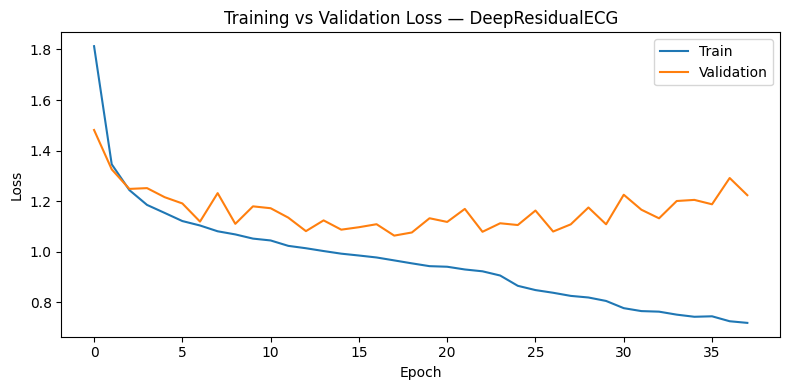

In [10]:
def plot_losses(train_losses, val_losses, save_path=None):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses,   label='Validation')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Training vs Validation Loss — DeepResidualECG')
    plt.legend(); plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f'Saved to {save_path}')
    plt.show()


train_mean_losses = []
valid_mean_losses = []
best_val_loss     = float('inf')
patience_count    = 0
best_epoch        = 0

model.train()

for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{EPOCHS} ---')
    batch_losses = []

    for i, (X_batch, y_batch) in enumerate(train_loader):
        print(f'  batch {i+1}/{len(train_loader)}', end='\r', flush=True)
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    mean_train = np.mean(batch_losses)
    mean_val   = compute_val_loss(model, dev_loader)
    train_mean_losses.append(mean_train)
    valid_mean_losses.append(mean_val)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Train loss: {mean_train:.4f}  |  Val loss: {mean_val:.4f}  |  LR: {current_lr:.2e}')

    scheduler.step(mean_val)

    if mean_val < best_val_loss:
        best_val_loss  = mean_val
        best_epoch     = epoch
        patience_count = 0
        ckpt_path = os.path.join(MODEL_SAVE_DIR, f'residual_cnn_best_epoch{epoch}.pt')
        torch.save(model.state_dict(), ckpt_path)
        print(f'  ** Best model saved -> {ckpt_path}')
    else:
        patience_count += 1
        print(f'  No improvement. Patience: {patience_count}/{PATIENCE}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}. Best: {best_epoch}')
        break

plot_losses(train_mean_losses, valid_mean_losses,
            save_path=os.path.join(MODEL_SAVE_DIR, 'residual_cnn_loss_curve.png'))

## 9. Evaluation on Test Set

Set best epoch if model saved

In [ ]:
# best_epoch = 18

In [11]:
best_ckpt = os.path.join(MODEL_SAVE_DIR, f'residual_cnn_best_epoch{best_epoch}.pt')
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print(f'Loaded best model from epoch {best_epoch}')

print('\nOptimizing thresholds on validation set...')
thr = threshold_optimization(model, dev_loader)
print(f'Thresholds (MI, STTC, CD, HYP): {thr}')

print('\nEvaluating on test set...')
matrix, norm_vec, n_exact, n_total            = evaluate(model, test_loader, thr)
per_class_auroc, macro_auroc, micro_auroc     = eval_auroc(model, test_loader)
print_metrics(matrix, norm_vec, per_class_auroc, macro_auroc, micro_auroc,
              n_exact=n_exact, n_total=n_total, split='Test')

Loaded best model from epoch 18

Optimizing thresholds on validation set...
Thresholds (MI, STTC, CD, HYP): [0.51 0.52 0.82 0.82]

Evaluating on test set...
  eval 9/9
Test Results
Class     Sensitivity  Specificity   F1-score   Accuracy    AUROC
------------------------------------------------------------------------
MI             0.7993       0.8547     0.7193     0.8405   0.9022
STTC           0.8910       0.8055     0.7125     0.8262   0.9266
CD             0.7972       0.8799     0.7251     0.8608   0.9130
HYP            0.7909       0.6695     0.3785     0.6842   0.8119
AD             0.7371       0.9048     0.7894     0.8340      N/A
------------------------------------------------------------------------
Macro          0.8031       0.8229     0.6650     0.8092   0.8884
Micro          0.8236       0.7974     0.6396     0.8029   0.8649
------------------------------------------------------------------------
Exact match (subset) accuracy: 1004/2163 = 0.4642


## 10. Confusion Matrices

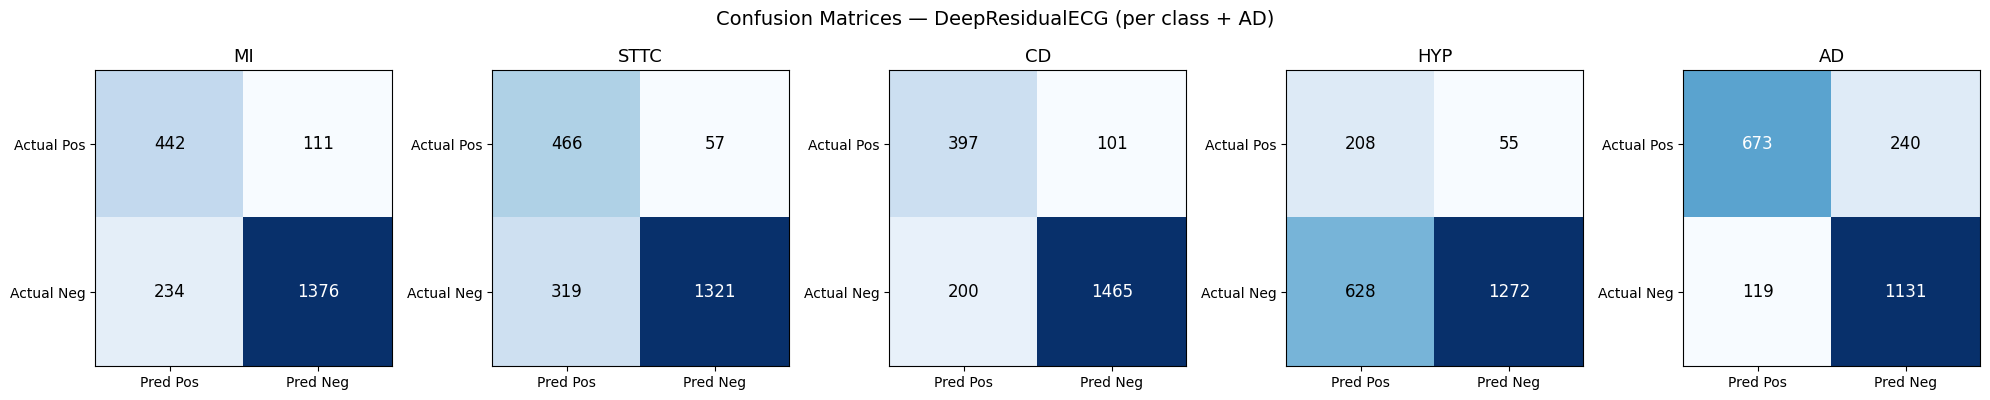

In [12]:
all_cms   = [matrix[i] for i in range(N_CLASSES)] + [norm_vec]
all_names = ['MI', 'STTC', 'CD', 'HYP', 'AD']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, name, counts in zip(axes, all_names, all_cms):
    tp, fn, fp, tn = counts
    cm = np.array([[int(tp), int(fn)], [int(fp), int(tn)]])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=13)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Pos', 'Pred Neg'])
    ax.set_yticklabels(['Actual Pos', 'Actual Neg'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha='center', va='center',
                    color='white' if cm[r, c] > cm.max()/2 else 'black', fontsize=12)

plt.suptitle('Confusion Matrices — DeepResidualECG (per class + AD)', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrices.png'))
plt.show()

## 11. XAI — Grad-CAM on Raw ECG Signals

Grad-CAM adapted for the temporal domain.

- Hook target: **`block4` output** — shape `(B, 128, leads, ~55)`
- Grad-CAM weights each activation map by the mean gradient of the target class score
- Result upsampled from `~55` → `1000` time steps per lead
- **Red shading** = time regions most important for the predicted class

In [13]:
CLASS_NAMES = ['MI', 'STTC', 'CD', 'HYP']

LEAD_NAME_MAP = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_LABELS   = [LEAD_NAME_MAP[i] for i in LEAD_INDICES]


class GradCAM1D:
    """
    Grad-CAM for DeepResidualECG.

    Hooks onto block4's output (B, 128, leads, ~55).
    Returns a per-lead temporal heatmap (leads, 1000) in [0, 1],
    upsampled to the original signal length.
    """

    def __init__(self, model):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._hooks = [
            model.block4.register_forward_hook(
                lambda m, inp, out: setattr(self, 'activations', out.detach())
            ),
            model.block4.register_full_backward_hook(
                lambda m, gin, gout: setattr(self, 'gradients', gout[0].detach())
            ),
        ]

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

    def __call__(self, input_tensor, class_idx):
        self.model.eval()
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, class_idx].backward()

        # Global-average-pool the gradients over (leads, time) → (1, 128, 1, 1)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted sum of activations + ReLU → (leads, time_reduced)
        cam = torch.relu((weights * self.activations).sum(dim=1))[0]  # (leads, ~55)

        # Upsample to original 1000 time steps
        cam = torch.nn.functional.interpolate(
            cam.unsqueeze(0).unsqueeze(0),      # (1, 1, leads, ~55)
            size=(cam.shape[0], 1000),
            mode='bilinear',
            align_corners=False,
        ).squeeze(0).squeeze(0)                  # (leads, 1000)

        cam = cam.cpu().numpy()
        mn, mx = cam.min(), cam.max()
        if mx > mn:
            cam = (cam - mn) / (mx - mn)
        return cam


def run_gradcam_signal(model, sample_idx, partition='test',
                       target_class=None, thr=None, save_path=None):
    """
    Overlay Grad-CAM heatmap on the raw ECG signals.
    Red shading intensity = importance for the target class at each time step.

    Parameters
    ----------
    target_class : int or None
        0=MI, 1=STTC, 2=CD, 3=HYP. None → uses argmax of predicted probabilities.
    """
    part_map = {'train': (X_train, y_train), 'dev': (X_dev, y_dev), 'test': (X_test, y_test)}
    X_part, y_part = part_map[partition]

    signal = X_part[sample_idx]   # (1, leads, 1000)
    label  = y_part[sample_idx]   # (4,)

    input_tensor = torch.from_numpy(signal).unsqueeze(0).to(DEVICE)  # (1, 1, leads, 1000)

    # ── Forward pass ─────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]   # (4,)

    if thr is not None:
        pred       = (probs > thr).astype(int)
        pred_label = 'AD' if not any(pred) else '+'.join(n for n, v in zip(CLASS_NAMES, pred) if v)
    else:
        pred_label = None

    if target_class is None:
        target_class = int(np.argmax(probs))

    gt_label = 'AD' if not any(label.astype(int)) else '+'.join(
        n for n, v in zip(CLASS_NAMES, label.astype(int)) if v)

    # ── Grad-CAM ─────────────────────────────────────────────────────────────
    gc  = GradCAM1D(model)
    cam = gc(input_tensor, target_class)   # (leads, 1000)
    gc.remove_hooks()

    # ── Plot ─────────────────────────────────────────────────────────────────
    time_axis = np.arange(1000) / 100.0   # seconds (100 Hz)

    fig, axes = plt.subplots(NUM_LEADS, 1, figsize=(14, 2.5 * NUM_LEADS), sharex=True)
    if NUM_LEADS == 1:
        axes = [axes]

    gt_str   = '  '.join(f'{n}={int(v)}'   for n, v in zip(CLASS_NAMES, label))
    pred_str = '  '.join(f'{n}={v:.3f}' for n, v in zip(CLASS_NAMES, probs))
    fig.suptitle(
        f'Grad-CAM  |  {partition.capitalize()} sample {sample_idx}\n'
        f'GT:   {gt_str}  →  {gt_label}\n'
        f'Pred: {pred_str}  →  {pred_label}\n'
        f'Grad-CAM target class: {CLASS_NAMES[target_class]}',
        fontsize=9, family='monospace', y=1.01,
    )

    for k, ax in enumerate(axes):
        sig  = signal[0, k, :]   # (1000,) ECG signal for this lead
        heat = cam[k]            # (1000,) importance for this lead

        ymin = sig.min() - 0.4
        ymax = sig.max() + 0.4

        # Heatmap background (imshow is fast — no axvspan loop)
        ax.imshow(
            heat.reshape(1, -1),
            aspect='auto',
            extent=[0, 10, ymin, ymax],
            cmap='Reds',
            alpha=0.5,
            origin='lower',
            vmin=0, vmax=1,
        )

        ax.plot(time_axis, sig, color='black', linewidth=0.8, zorder=2)
        ax.set_ylabel(f'Lead {LEAD_LABELS[k]}', fontsize=9)
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(0, 10)
        ax.tick_params(axis='y', labelsize=7)

    axes[-1].set_xlabel('Time (s)', fontsize=9)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()

print('GradCAM1D ready.')

GradCAM1D ready.


Saved to /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models_residual_cnn/gradcam_test_42.png


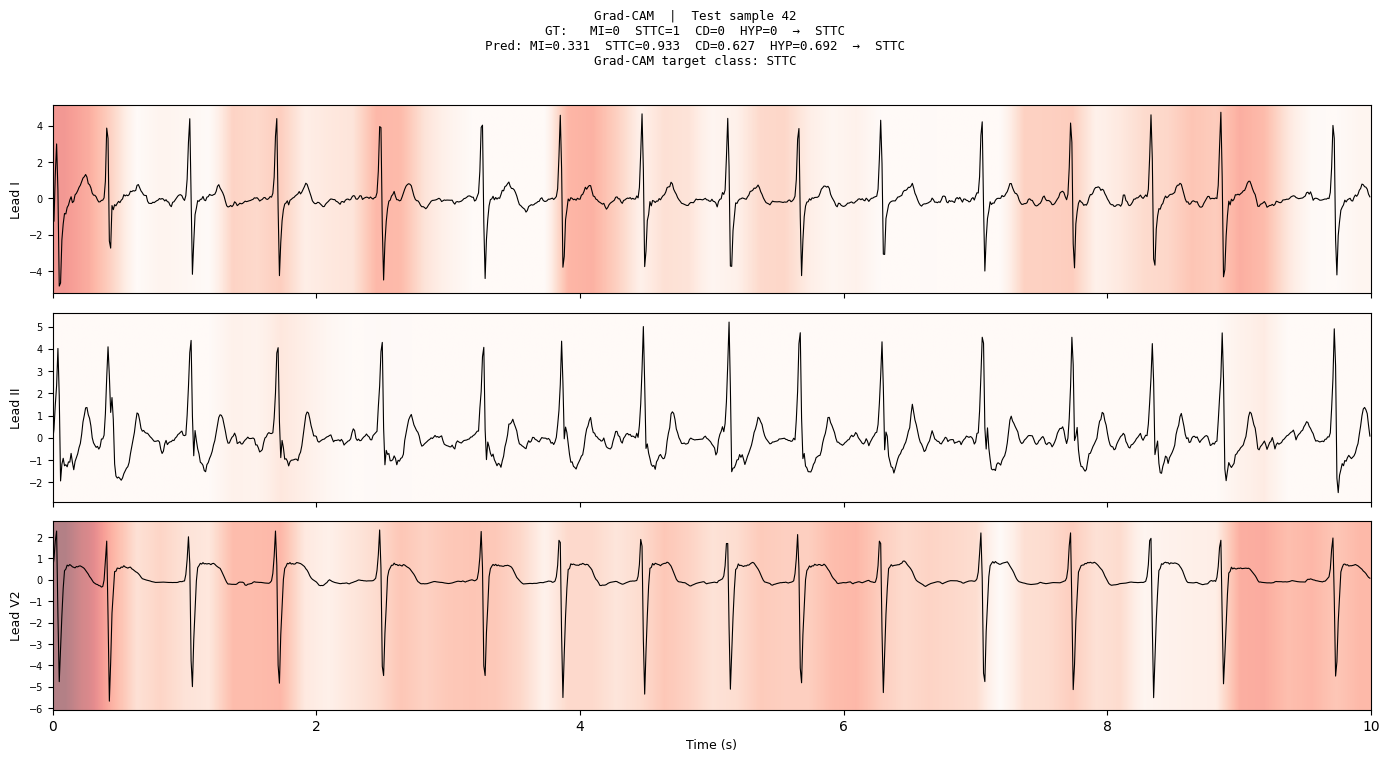

In [14]:
# ── Grad-CAM usage ────────────────────────────────────────────────────────────
# Change these to explore different samples and target classes
SAMPLE_IDX   = 42        # index into the chosen partition
PARTITION    = 'test'    # 'train' | 'dev' | 'test'
TARGET_CLASS = None      # None=argmax of probs; 0=MI, 1=STTC, 2=CD, 3=HYP

run_gradcam_signal(
    model,
    sample_idx   = SAMPLE_IDX,
    partition    = PARTITION,
    target_class = TARGET_CLASS,
    thr          = thr,
    save_path    = os.path.join(MODEL_SAVE_DIR, f'gradcam_{PARTITION}_{SAMPLE_IDX}.png'),
)